In [42]:

import pandas as pd 

In [43]:
data = pd.read_csv("./Dataset/train.csv")
valid = pd.read_csv("./Dataset/validation.csv")

print(data.shape)
print(valid.shape)

print(data.columns.equals(valid.columns))


(130319, 5)
(11873, 5)
True


In [44]:
data = pd.concat([data, valid], axis=0, ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

data.head()

,id,title,context,question,answers
0,57269ef4f1498d1400e8e52d,The_Sun_(United_Kingdom),Despite its initial opposition to the closures...,What's another thing the paper showed hostilit...,{'text': array(['promotion of right-wing minis...
1,56dfbd5e231d4119001abd5a,Internet_service_provider,"ISPs provide Internet access, employing a ran...",what type of technology is used to connect to ...,"{'text': array(['wireless Ethernet (wi-fi)'], ..."
2,5730d22faca1c71400fe5af0,United_States_Air_Force,"Offensive Counterair (OCA) is defined as ""offe...",What is one of the important functions of the ...,{'text': array(['suppression/destruction of en...
3,57266715dd62a815002e83be,British_Empire,The Caribbean initially provided England's mos...,When did England first establish a colony in G...,"{'text': array(['1604'], dtype=object), 'answe..."
4,5706371452bb89140068996f,MP3,"When performing lossy audio encoding, such as ...",What would an example of lossy audio encoding be?,"{'text': array(['creating an MP3 file'], dtype..."


In [45]:
data.shape

(142192, 5)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142192 entries, 0 to 142191
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        142192 non-null  object
 1   title     142192 non-null  object
 2   context   142192 non-null  object
 3   question  142192 non-null  object
 4   answers   142192 non-null  object
dtypes: object(5)
memory usage: 5.4+ MB


In [47]:
# check sui duplicati 
data.duplicated(subset=["context", "question", "answer_text"]).sum()

KeyError: Index(['answer_text'], dtype='object')

In [39]:
data = data.drop_duplicates(subset=["context", "question", "answer_text"]).reset_index(drop=True)
data.duplicated(subset=["context", "question", "answer_text"]).sum()


np.int64(0)

In [40]:
print("Nuova size:", data.shape)


Nuova size: (142162, 11)


In [41]:
print(data.columns)

Index(['id', 'title', 'context', 'question', 'answers', 'context_length',
       'context_word_count', 'question_length', 'question_word_count',
       'answer_text', 'answer_word_count'],
      dtype='object')


In [ ]:
# lunghezza testo
data["context_length"] = data["context"].str.len()
data["context_word_count"] = data["context"].str.split().apply(len)

data[["context_length", "context_word_count"]].describe()



,context_length,context_word_count
count,154065.000000,154065.000000
mean,763.260260,120.892493
std,316.579717,50.789342
min,151.000000,20.000000
25%,566.000000,90.000000
50%,696.000000,110.000000
75%,898.000000,142.000000
max,4063.000000,653.000000


In [ ]:
# fare boxplot!!!!!!

In [28]:
data["question_length"] = data["question"].str.len()
data["question_word_count"] = data["question"].str.split().apply(len)

data[["question_length", "question_word_count"]].describe()


,question_length,question_word_count
count,154065.000000,154065.000000
mean,58.661630,9.913212
std,68.326311,3.429969
min,1.000000,1.000000
25%,44.000000,7.000000
50%,56.000000,9.000000
75%,70.000000,12.000000
max,25651.000000,40.000000


In [ ]:
# estraiamo testo dalla risposta 
import re

def extract_answer_text(s):
    match = re.search(r"array\(\['(.*?)'\]", s)
    return match.group(1) if match else ""

data["answer_text"] = data["answers"].apply(extract_answer_text)



In [ ]:
data["answer_word_count"] = data["answer_text"].str.split().apply(len)
data["answer_word_count"].describe()


count    154065.000000
mean          1.928368
std           2.988376
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          43.000000
Name: answer_word_count, dtype: float64

In [33]:
data[["answer_text"]].head()


,answer_text
0,
1,
2,
3,a movie
4,1855


In [34]:
# domande senza risposta 
(data["answer_text"] == "").sum()

np.int64(62384)

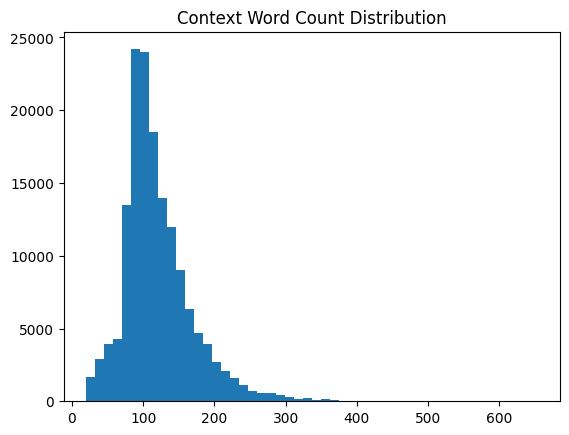

In [35]:
import matplotlib.pyplot as plt

plt.hist(data["context_word_count"], bins=50)
plt.title("Context Word Count Distribution")
plt.show()
